In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')

In [ ]:
clinical_variable_palette = {
    'Responder': 'midnightblue',
    'Non-responder': 'lightsteelblue',
}

In [17]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Helvetica'
matplotlib.rcParams.update({'font.size': 10})

# Load Sade-Feldman 2018 dataset

In [5]:
adata = sc.read_h5ad(os.path.expanduser("sade-feldman-2018/sade_feldman_2018_annotated.h5ad"))

In [6]:
keep = ['sample_id', 'Sample name', 'patient_timepoint', 'response', 'therapy', 'sample_name', 'patient_id',
       'biopsy_type', 'days_on_therapy', 'biopsy_site',
       'biopsy_lesion_response', 'biopsy_response_status', 'gender', 'age',
       'therapy_detail', 'recist_response_detail', 'os_days',
       'os_status', 'driver_mutations', 'ifn_pathway_mutations', 'G_cluster',
       'G_cluster_name', 'CD8_BG', 'CD8_subcluster']
adata.obs = adata.obs[keep]

In [7]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


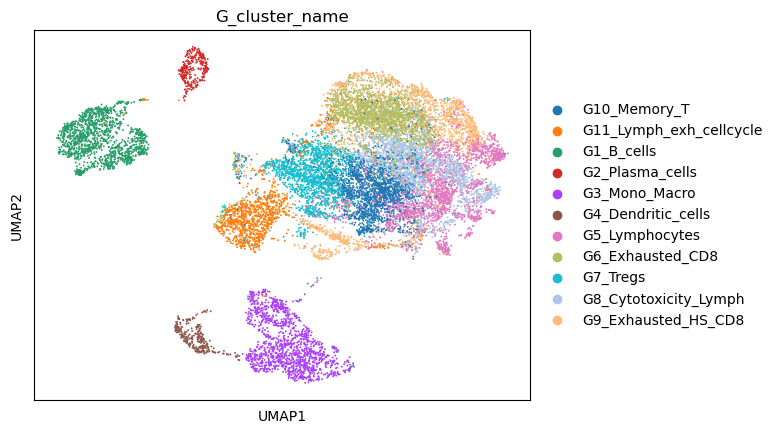

In [8]:
sc.pl.umap(adata, color='G_cluster_name')

# CD8+CD4 T (lymphocytes)

In [9]:
tcells = adata[adata.obs['G_cluster'].isin([5,6,7,8,9,10,11])]

sc.pp.pca(tcells)
sc.pp.neighbors(tcells)
sc.tl.umap(tcells)

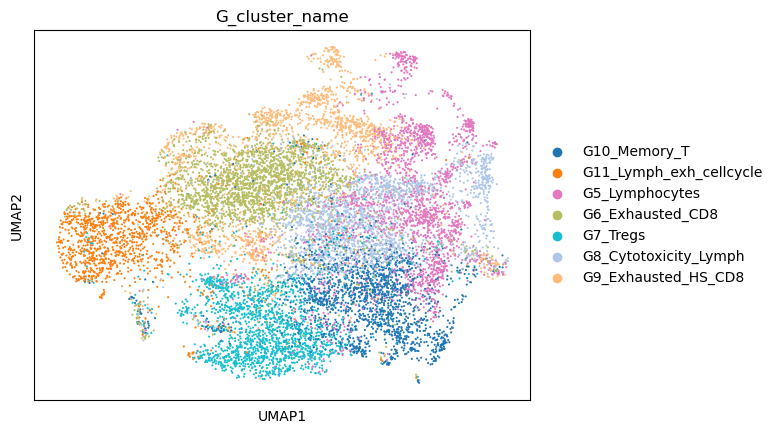

In [10]:
sc.pl.umap(tcells, color='G_cluster_name')

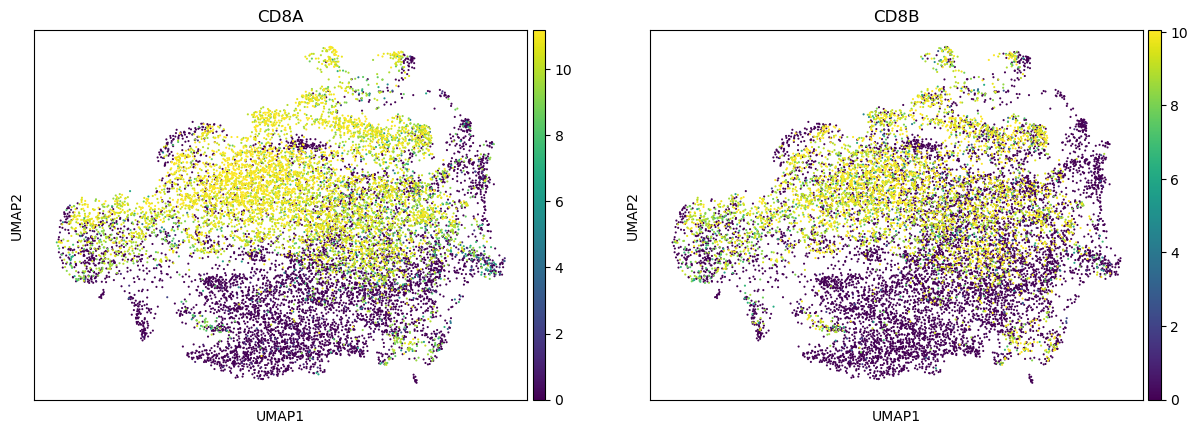

In [11]:
sc.pl.umap(tcells, color=['CD8A','CD8B'], vmax='p90')

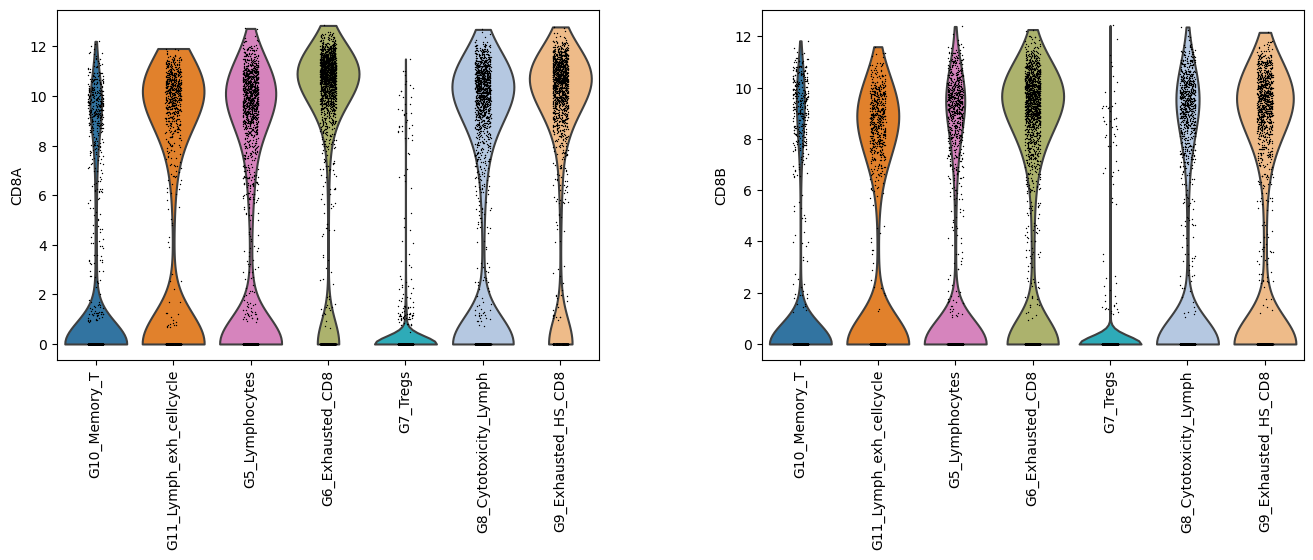

In [12]:
ax = sc.pl.violin(tcells, ['CD8A','CD8B'], groupby='G_cluster_name', rotation=90)

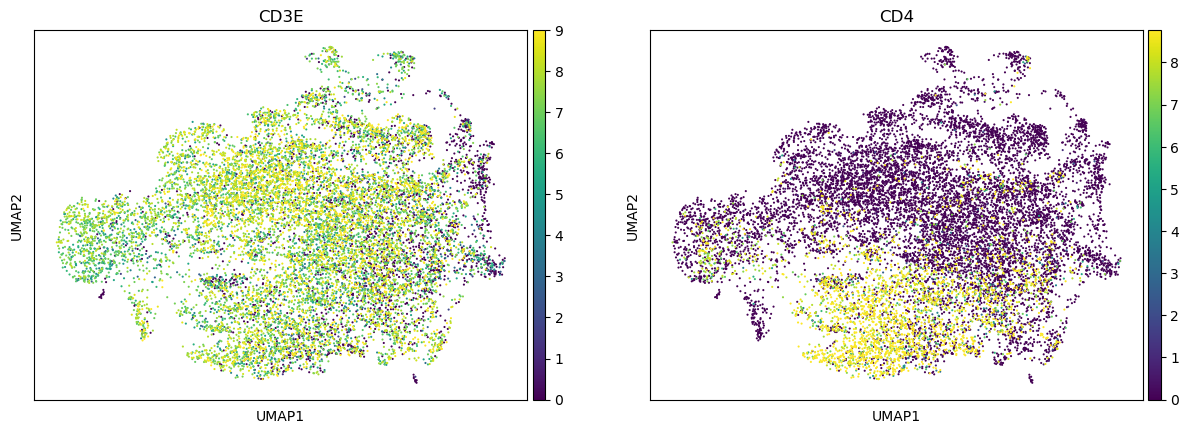

In [13]:
sc.pl.umap(tcells, color=['CD3E','CD4'], vmax='p90')

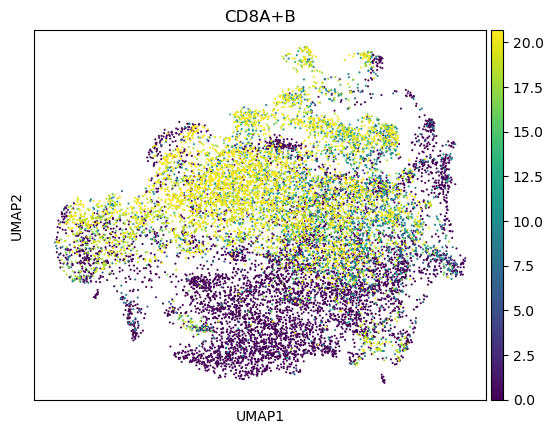

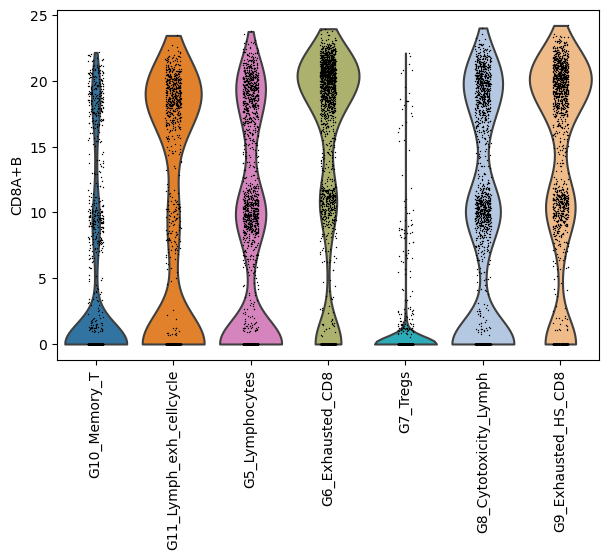

In [14]:
tcells.obs['CD8A+B'] = tcells[:,['CD8A','CD8B']].X.sum(axis=1)
sc.pl.umap(tcells, color='CD8A+B', vmax='p90')
sc.pl.violin(tcells, 'CD8A+B', groupby='G_cluster_name', rotation=90)

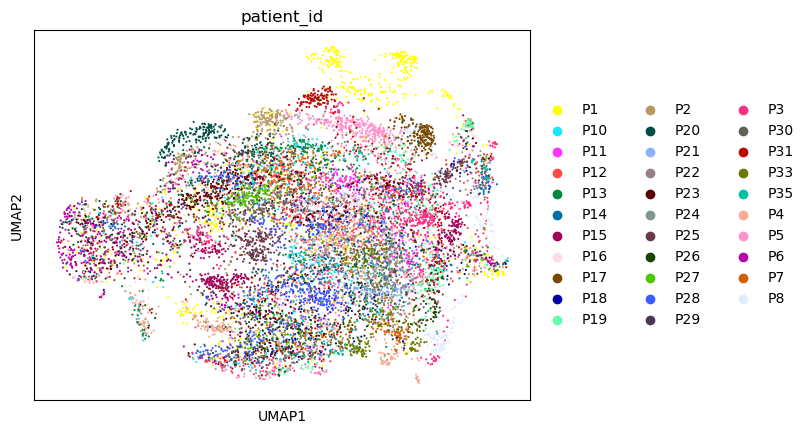

In [15]:
sc.pl.umap(tcells, color='patient_id')

# CD8 T only

In [16]:
cd8t = adata[adata.obs['CD8_BG'].notna()].copy()
cd8t

AnnData object with n_obs × n_vars = 6389 × 55737
    obs: 'sample_id', 'Sample name', 'patient_timepoint', 'response', 'therapy', 'sample_name', 'patient_id', 'biopsy_type', 'days_on_therapy', 'biopsy_site', 'biopsy_lesion_response', 'biopsy_response_status', 'gender', 'age', 'therapy_detail', 'recist_response_detail', 'os_days', 'os_status', 'driver_mutations', 'ifn_pathway_mutations', 'G_cluster', 'G_cluster_name', 'CD8_BG', 'CD8_subcluster'
    uns: 'G_cluster_names', 'dataset', 'expression_units', 'pca', 'neighbors', 'umap', 'G_cluster_name_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [17]:
sc.pp.pca(cd8t)
sc.pp.neighbors(cd8t)
sc.tl.umap(cd8t)

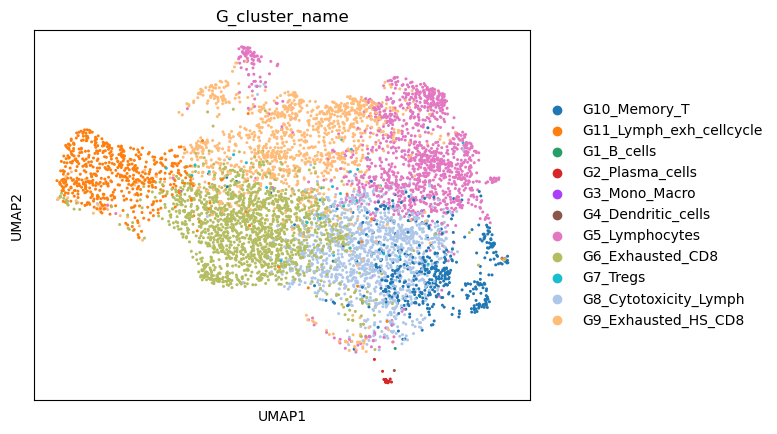

In [18]:
sc.pl.umap(cd8t, color='G_cluster_name')

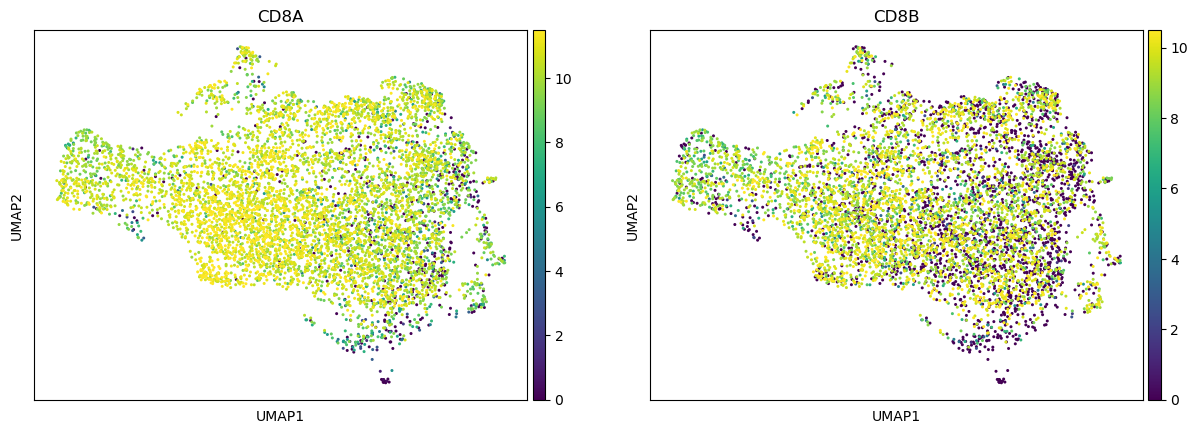

In [19]:
sc.pl.umap(cd8t, color=['CD8A','CD8B'], vmax='p90')

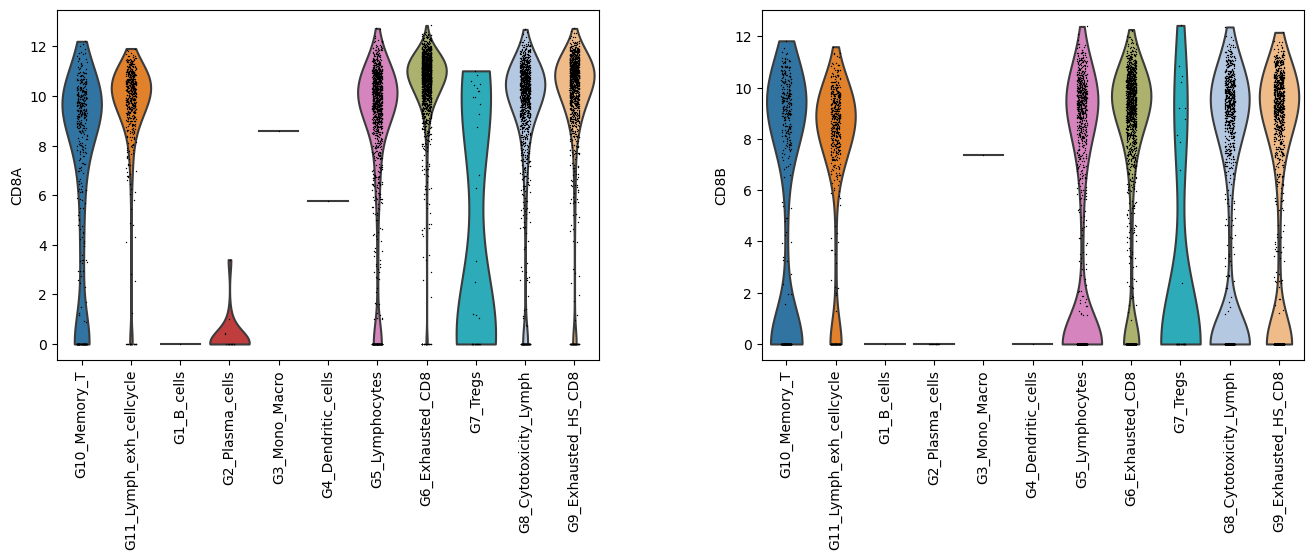

In [20]:
ax = sc.pl.violin(cd8t, ['CD8A','CD8B'], groupby='G_cluster_name', rotation=90)

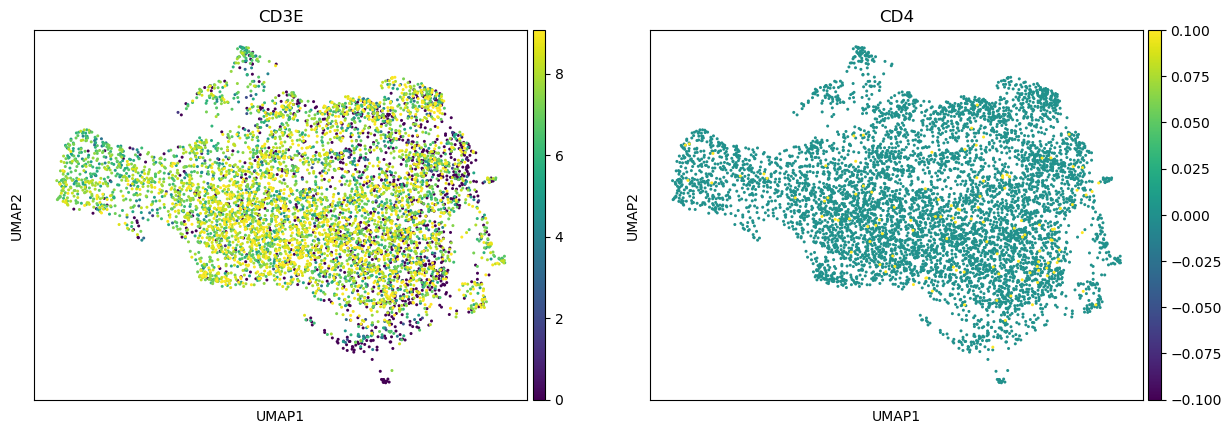

In [21]:
sc.pl.umap(cd8t, color=['CD3E','CD4'], vmax='p90')

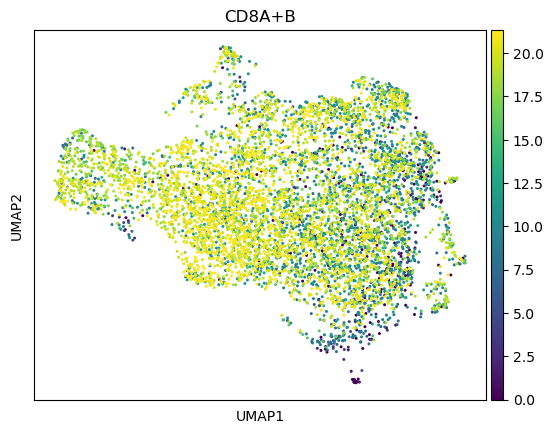

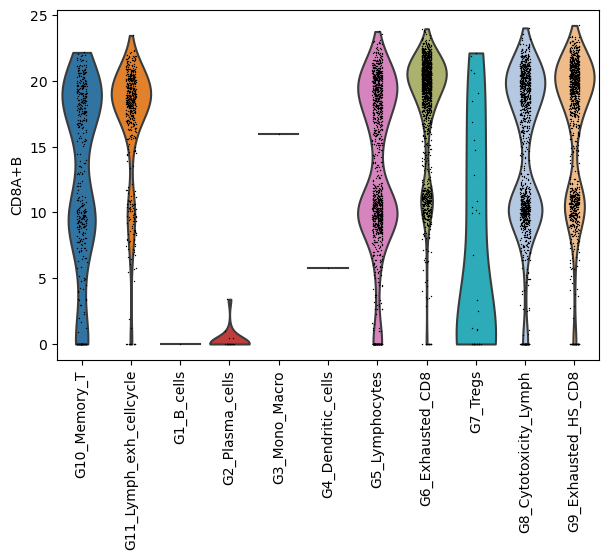

In [22]:
cd8t.obs['CD8A+B'] = cd8t[:,['CD8A','CD8B']].X.sum(axis=1)
sc.pl.umap(cd8t, color='CD8A+B', vmax='p90')
sc.pl.violin(cd8t, 'CD8A+B', groupby='G_cluster_name', rotation=90)

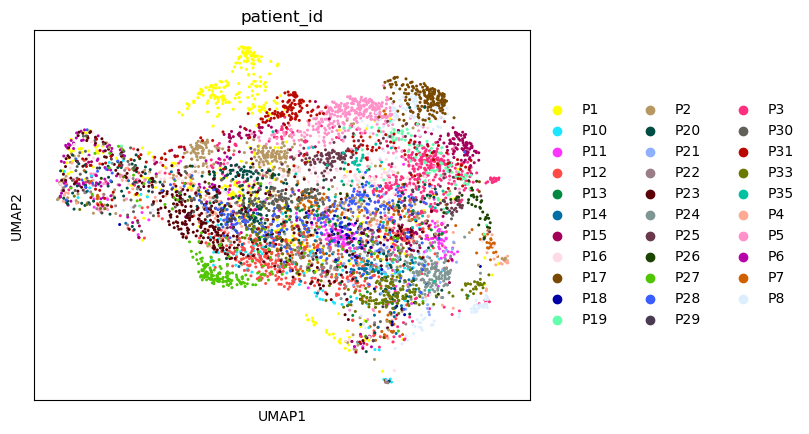

In [23]:
sc.pl.umap(cd8t, color='patient_id')

## define days on treatment buckets

In [72]:
# days_on_therapy is negative --> screening bioppsy taken before day of treatment. clip to 0
# days_on_therapy is days from baseline to biopsy collection, not duration of therapy. Doesn't report dates of discontinuation; time on drug can't be derived for NR who progressed and switched
# response is R/NR; recist_response_detail is broken out
print(cd8t.obs.columns)
cd8t.obs

Index(['sample_id', 'Sample name', 'patient_timepoint', 'response', 'therapy',
       'sample_name', 'patient_id', 'biopsy_type', 'days_on_therapy',
       'biopsy_site', 'biopsy_lesion_response', 'biopsy_response_status',
       'gender', 'age', 'therapy_detail', 'recist_response_detail', 'os_days',
       'os_status', 'driver_mutations', 'ifn_pathway_mutations', 'G_cluster',
       'G_cluster_name', 'CD8_BG', 'CD8_subcluster', 'CD8A+B',
       'therapy_bucket'],
      dtype='object')


,sample_id,Sample name,patient_timepoint,response,therapy,sample_name,patient_id,biopsy_type,days_on_therapy,biopsy_site,...,os_days,os_status,driver_mutations,ifn_pathway_mutations,G_cluster,G_cluster_name,CD8_BG,CD8_subcluster,CD8A+B,therapy_bucket
cell_id,,,,,,,,,,,,,,,,,,,,,
A2_P4_M11,Pre_P1,Sample 8,Pre_P1,Responder,anti-CTLA4,Pre_P1,P1,Baseline,0,right chest,...,822,0,"BRAF, CDKN2A","IFI16, IFIH1, STAT4",5.0,G5_Lymphocytes,CD8_G,CD8_4,8.910000,Pre-Treatment
A4_P3_M11,Pre_P1,Sample 11,Pre_P1,Responder,anti-CTLA4,Pre_P1,P1,Baseline,0,right chest,...,822,0,"BRAF, CDKN2A","IFI16, IFIH1, STAT4",9.0,G9_Exhausted_HS_CD8,CD8_B,CD8_2,18.700001,Pre-Treatment
A4_P4_M11,Pre_P1,Sample 12,Pre_P1,Responder,anti-CTLA4,Pre_P1,P1,Baseline,0,right chest,...,822,0,"BRAF, CDKN2A","IFI16, IFIH1, STAT4",9.0,G9_Exhausted_HS_CD8,CD8_B,CD8_2,10.100000,Pre-Treatment
A4_P6_M11,Pre_P1,Sample 13,Pre_P1,Responder,anti-CTLA4,Pre_P1,P1,Baseline,0,right chest,...,822,0,"BRAF, CDKN2A","IFI16, IFIH1, STAT4",5.0,G5_Lymphocytes,CD8_G,CD8_4,16.220001,Pre-Treatment
A6_P6_M11,Pre_P1,Sample 18,Pre_P1,Responder,anti-CTLA4,Pre_P1,P1,Baseline,0,right chest,...,822,0,"BRAF, CDKN2A","IFI16, IFIH1, STAT4",9.0,G9_Exhausted_HS_CD8,CD8_B,CD8_2,21.110001,Pre-Treatment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H10_P1_M39_T_enriched,Post_P2_T_enriched,Sample 15488,Post_P2,Non-responder,anti-PD1,Post_P2,P2,Post I,35,left axilla,...,347,1,"BRAF, PTEN",ND,9.0,G9_Exhausted_HS_CD8,CD8_B,CD8_2,0.000000,0 - 61.00 days
H12_P1_M39_T_enriched,Post_P2_T_enriched,Sample 15490,Post_P2,Non-responder,anti-PD1,Post_P2,P2,Post I,35,left axilla,...,347,1,"BRAF, PTEN",ND,11.0,G11_Lymph_exh_cellcycle,CD8_B,CD8_1,5.690000,0 - 61.00 days
H3_P1_M39_T_enriched,Post_P2_T_enriched,Sample 15493,Post_P2,Non-responder,anti-PD1,Post_P2,P2,Post I,35,left axilla,...,347,1,"BRAF, PTEN",ND,11.0,G11_Lymph_exh_cellcycle,CD8_B,CD8_1,0.000000,0 - 61.00 days


In [73]:
positive_values = cd8t.obs['days_on_therapy'][cd8t.obs['days_on_therapy'] > 0]
quantiles = np.quantile(positive_values, [0.333, 0.666])-1 # turn into left cutoff
print(quantiles)

[ 66. 198.]


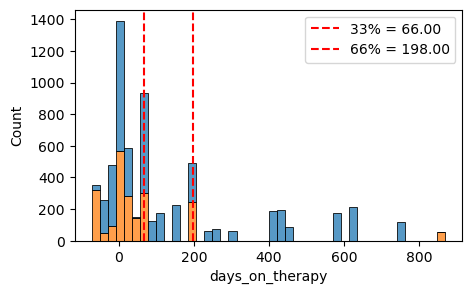

In [74]:
plt.figure(figsize=(5, 3))
ax = sns.histplot(cd8t.obs, x='days_on_therapy', hue='response', multiple='stack')
for q in quantiles:
    ax.axvline(q, color='red', linestyle='--', label=f'Quantile {q:.2f}')
ax.legend([f'33% = {quantiles[0]:.2f}', f'66% = {quantiles[1]:.2f}'])

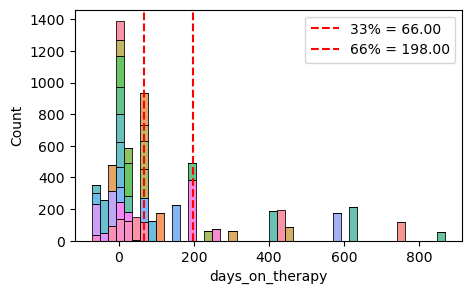

In [75]:
plt.figure(figsize=(5, 3))
ax = sns.histplot(cd8t.obs, x='days_on_therapy', hue='patient_id', multiple='stack')
for q in quantiles:
    ax.axvline(q, color='red', linestyle='--', label=f'Quantile {q:.2f}')
ax.legend([f'33% = {quantiles[0]:.2f}', f'66% = {quantiles[1]:.2f}'])

In [76]:
# Define patient buckets based on days_on_therapy quantiles above
def assign_bucket(days_on_therapy):
    if days_on_therapy <= 0:
        return 'Pre-Treatment'
    elif days_on_therapy <= quantiles[0]:
        return f'0 - {quantiles[0]:.2f} days'
    elif days_on_therapy <= quantiles[1]:
        return f'{quantiles[0]:.2f} - {quantiles[1]:.2f} days'
    else:
        return f'> {quantiles[1]:.2f} days'

therapy_bucket_order = ['Pre-Treatment', 
                       f'0 - {quantiles[0]:.2f} days', 
                       f'{quantiles[0]:.2f} - {quantiles[1]:.2f} days', 
                       f'> {quantiles[1]:.2f} days']
cd8t.obs['therapy_bucket'] = cd8t.obs['days_on_therapy'].apply(assign_bucket)
cd8t.obs['therapy_bucket'] = pd.Categorical(cd8t.obs['therapy_bucket'], categories=therapy_bucket_order, ordered=True)

[None, None, None, None, None, None, None, None]

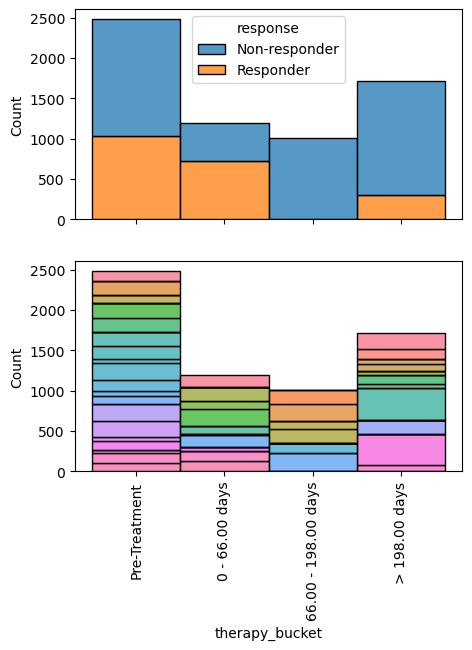

In [77]:
fig,axs = plt.subplots(2,1,figsize=(5, 6), sharex=True)
sns.histplot(cd8t.obs, x='therapy_bucket', hue='response', multiple='stack', ax=axs[0])
sns.histplot(cd8t.obs, x='therapy_bucket', hue='patient_id', multiple='stack', ax=axs[1], legend=False)
plt.setp(axs[0].get_xticklabels(), rotation=90)
plt.setp(axs[1].get_xticklabels(), rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'Pre-Treatment'),
  Text(1, 0, '0 - 66.00 days'),
  Text(2, 0, '66.00 - 198.00 days'),
  Text(3, 0, '> 198.00 days')])

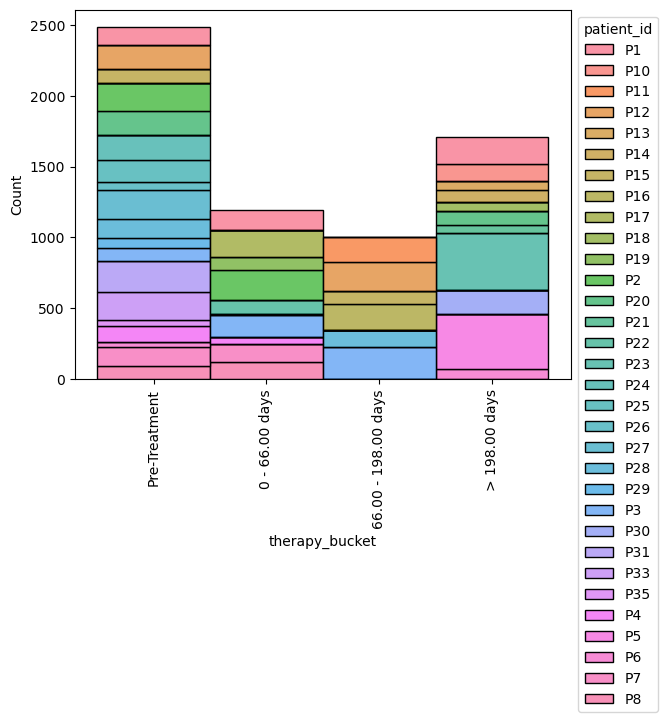

In [78]:
ax = sns.histplot(cd8t.obs, x='therapy_bucket', hue='patient_id', multiple='stack')
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=90)

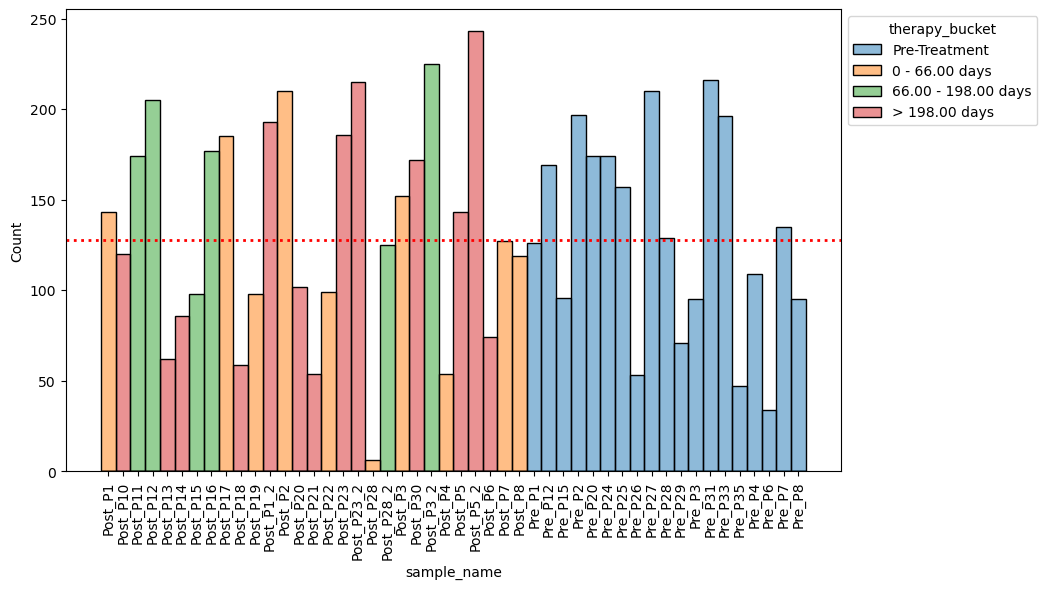

In [79]:
# subsampling may not be needed
plt.figure(figsize=(10, 6))
ax = sns.histplot(cd8t.obs, x='sample_name', hue='therapy_bucket')
median = cd8t.obs['sample_name'].value_counts().median()
ax.axhline(median, color='red', linestyle=':', linewidth=2, label='Median')
plt.xticks(rotation=90)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

In [96]:
cd8t.write_h5ad('sade-feldman-2018/sade_feldman_cd8t_annotated_062026.h5ad')

# CD8 T only (statistical sig figures)

In [5]:
cd8t = sc.read_h5ad('sade-feldman-2018/sade_feldman_cd8t_annotated_062026.h5ad')
cd8t

AnnData object with n_obs × n_vars = 6389 × 55737
    obs: 'sample_id', 'Sample name', 'patient_timepoint', 'response', 'therapy', 'sample_name', 'patient_id', 'biopsy_type', 'days_on_therapy', 'biopsy_site', 'biopsy_lesion_response', 'biopsy_response_status', 'gender', 'age', 'therapy_detail', 'recist_response_detail', 'os_days', 'os_status', 'driver_mutations', 'ifn_pathway_mutations', 'G_cluster', 'G_cluster_name', 'CD8_BG', 'CD8_subcluster', 'CD8A+B', 'therapy_bucket'
    uns: 'G_cluster_name_colors', 'G_cluster_names', 'dataset', 'expression_units', 'neighbors', 'patient_id_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
# Stem/Progenitor (Z3)
z3 = [
    "LEF1", "LINC00861", "RIPOR2", "TCF7", "IL7R", "NR3C2", "CCR7", "SORL1", "FOXP1", "BACH2",
    "TRABD2A", "SELL", "CAMK4", "RNF144A", "ANK3", "MGAT4A", "IGF1R", "ITGA6", "ACTN1", "MCUB",
    "TC2N", "PCSK5", "AC119396.1", "LEF1-AS1", "PRKN", "RASGRF2", "APBA2", "PCAT1", "SSBP2",
    "TNFAIP8", "SERINC5", "OXNAD1", "TXK", "SLC39A10", "FAM117B", "NRCAM", "SATB1-AS1", "MAML2",
    "PITPNC1", "EPHA1-AS1", "MPP7", "LTB", "SVIL", "MAN1C1", "SCML1", "GNAQ", "KCNQ1", "IMMP2L",
    "PLAC8", "TMEM63A", "SH3RF3", "PRMT2", "P2RY8", "PRKCQ-AS1", "FMN1", "RETREG1", "SBF2", 
    "SLC16A10", "AC233976.1", "DOCK9", "FP671120.4", "TMEM123", "LINC01550", "NBEA", "UBE2E2", 
    "LINC00402", "SCML4", "CHRM3-AS2", "KANK1", "MAML3", "ADD3", "PATJ", "RASA3", "TMEM131L", 
    "MBNL1", "AL353660.1", "KLF2", "AC002460.2", "SAMD12", "AK5", "S1PR1", "AC093157.1", 
    "DENND5A", "AL163932.1", "LRRN3", "XIST", "GLIS3", "SLCO3A1", "TXNIP", "ANKH", "MGAT5", 
    "TMEM272", "RASSF3", "MAGI2", "AOAH", "CDC14A", "SAMD3", "RALGPS2", "TANC2", "EML4"
]
# Activation and Cytotoxicity (Z4)
z4 = [
    "AOAH", "AHNAK", "SAMD3", "TC2N", "GZMK", "NIBAN1", "PARP8", "PPP2R2B", "PTGDR",
    "IQGAP2", "STK39", "KLRG1", "AF165147.1", "ARHGAP26", "TPRG1", "PYHIN1", "AC006369.1",
    "AUTS2", "KLF6", "PLCB1", "ANXA1", "GZMA", "EMB", "PPP2R5C", "EML4", "TGFBR3", "ANK3",
    "C1orf21", "EPHA4", "MYBL1", "ZFP36L2", "MIAT", "CLDND1", "MSC-AS1", "FCRL6", "PTPRC",
    "ERN1", "A2M-AS1", "TTC39C", "IFNG-AS1", "PLEKHA5", "ST8SIA1", "ASAP1", "CD69", "PLCG2",
    "SLC4A7", "SMAD3", "GAB3", "USP9Y", "PRKY", "GPRIN3", "JAZF1", "STOM", "LINC00278", "HIP1",
    "DTHD1", "PHACTR2", "MAP3K5", "SLF1", "GNG2", "KIAA0825", "SLC4A4", "SLCO3A1", "IGLV2-14",
    "SLC9A9", "SLAMF6", "CASK", "AGAP1", "JAKMIP2", "LINC02320", "PDCD4", "GNAO1", "FYN",
    "ADRB2", "MBOAT1", "INPP4B", "LGR6", "CATSPERB", "ATXN1", "SLAMF7", "LCP1", "CCL5",
    "E2F3", "GPR183", "CEP128", "CRYBG1", "AC053513.1", "PZP", "USP28", "RAP1GAP2", "SH2D1A",
    "C12orf75", "PPP3CA", "FAR2", "MATK", "GBP5", "AC068587.4", "CCR4", "PDE4B", "IL32"
]
# Loss of Self-Renewal (Z2)
z2 = [
    "FKBP5", "AOAH", "ITGA1", "DAPK2", "PPP2R2B", "CMIP", "PARP8", "ITGAE", "SFMBT2", "LINC00426",
    "RAP1GDS1", "DTHD1", "RUNX1", "TRERF1", "TTN", "TSPAN5", "ST6GALNAC3", "MVB12B", "AC022126.1",
    "LINC01934", "KIAA1671", "LINC02694", "AL392086.3", "AF165147.1", "STARD9", "THEMIS", "CD38",
    "STK39", "FCRL6", "MAP3K5", "PLCG2", "IGKV4-1", "PECAM1", "ZNRF1", "AC243829.2", "ITGAL",
    "RASA1", "KLRC4", "PCNX1", "FAM53B", "MIAT", "DRAIC", "SUCLG2", "KATNAL1", "NAP1L4", "SLC9A9",
    "CD244", "CRIM1", "ABCB1", "SIRPG", "SPON2", "JAKMIP2", "YPEL1", "HIP1", "USP28", "CXCR6",
    "TOGARAM2", "KIAA0825", "UBL3", "MAP2K6", "PIK3AP1", "PTGDR", "GBP5", "MEAK7", "ADAMTS17",
    "PTPRJ", "FOXO1", "ARHGAP18", "LINC00278", "PDCD4", "DNAJC1", "ST8SIA1", "DAB2IP", "BFSP2-AS1",
    "IDH2", "HIST1H1E", "ZFP36L2", "MIR4435-2HG", "EPSTI1", "RUNX2", "MYO5A", "TC2N", "SNTB2",
    "GAB3", "ZEB1", "DZIP3", "MSC-AS1", "ADGRE5", "SP4", "EMB", "MAST4", "PIK3R5", "ASAP1", "RGS1",
    "CCDC141", "CSF1", "DDIT4", "CLIC5", "CCR9", "TET1"
]
# Exhaustion and Antigen-Presentation (Z9)
z9 = [
    "B2M", "NKG7", "HLA-A", "ENTPD1", "CCL5", "CD74", "ZC3H12C", "PRF1", "DGKH", "FTL", "PAM",
    "LYST", "MIR155HG", "HAVCR2", "TOX", "CSF1", "ACTB", "LAG3", "AL138720.1", "TNFRSF9", "IGF2R",
    "PDE7B", "SETBP1", "GPD2", "GAPDH", "CD8A", "FAM3C", "TNIP3", "NCALD", "ATP8B4", "RDH10",
    "HLA-DRB1", "STAT1", "AC024028.1", "PHLDA1", "HLA-C", "TIGIT", "IL2RB", "MTSS1", "HLA-B",
    "PTPRJ", "INPP5F", "TMSB4X", "AP001341.1", "MYO7A", "CD38", "ADGRG1", "AL133405.2", "CADM1",
    "FASLG", "GZMB", "FUT8", "CCL4", "FCRL3", "GOLIM4", "RIN3", "CST7", "MAN1A1", "GNLY",
    "LINC01943", "WHRN", "CD27", "KIR2DL4", "NFAT5", "AFAP1L2", "CCL3", "IFNG", "GBP2", "OSBPL3",
    "PFN1", "KLRD1", "PTMS", "VCAM1", "MAP4K3", "TAP1", "CTSC", "RGS3", "UBE2F", "TBC1D4",
    "TNFRSF1B", "CALR", "UTY", "PIP5K1B", "LINC00299", "CDK14", "CD7", "GZMH", "TRPS1", "LY6E",
    "ATP9A", "ARL6IP1", "AL355076.2", "CDK6", "GBP5", "APOBEC3G", "HCST", "HLA-DPA1", "ZFP36L1",
    "MTRNR2L12", "LINC02416"
]

In [10]:
therapy_bucket_order = ['Pre-Treatment', '0 - 66.00 days', '66.00 - 198.00 days', '> 198.00 days']

In [11]:
def p_to_stars(p):
    """Convert a p-value into conventional significance stars."""
    if p is None or np.isnan(p):
        return ''
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''


def add_significance_brackets(ax, sig_pairs, color='black', fontsize=12, line_height_frac=0.04, gap_frac=0.025):
    """
    Draw significance brackets with stars above an axes for each (x1, x2, pval) triple
    in sig_pairs whose stars are non-empty. Brackets are stacked at increasing height
    to avoid overlap, and the axes ylim is expanded to fit them.
    """
    sig_pairs = [(x1, x2, p) for x1, x2, p in sig_pairs if p_to_stars(p)]
    if not sig_pairs:
        return
    # narrower spans drawn lower (less visual clutter from wide brackets)
    sig_pairs = sorted(sig_pairs, key=lambda t: abs(t[1] - t[0]))

    y0, y1 = ax.get_ylim()
    span = y1 - y0
    h = span * line_height_frac
    gap = span * gap_frac
    level_y = y1 + gap

    for x1, x2, p in sig_pairs:
        stars = p_to_stars(p)
        y = level_y
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c=color, clip_on=False)
        ax.text((x1 + x2) / 2, y + h, stars, ha='center', va='bottom', fontsize=fontsize, clip_on=False)
        level_y += h + gap * 2.5

    ax.set_ylim(y0, level_y + h)

## examine cell-level expression patterns (responder vs. non-responder significance)

In [18]:
def plot_violin_with_responder_significance(cd8t, genes, therapy_bucket_order, palette, title=None, figsize=(10, 6), save_fig=None):
    genes = genes.copy()
    print(title)
    print("missing genes: ", len(set(genes) - set(cd8t.var_names)), ":", set(genes) - set(cd8t.var_names))
    genes = list(set(genes) & set(cd8t.var_names))

    df = sc.get.obs_df(cd8t, keys=genes + cd8t.obs.columns.tolist())
    key = "+".join(genes)
    df[key] = df[genes].sum(axis=1)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.violinplot(
        data=df, x='therapy_bucket', y=key, hue='response',
        order=therapy_bucket_order, hue_order=['Responder', 'Non-responder'],
        palette=palette, ax=ax,
    )
    ax.set_title(title if title else key)
    ax.set_xlabel('Days on ICB')
    ax.set_ylabel('Normalized Expression')
    ax.get_legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=30)

    # Responder vs. Non-responder significance within each therapy bucket
    # (Bonferroni correction: p-value * size of the larger of the two compared groups)
    print(f"\n--- Significance tests for '{key}': Responder vs Non-responder within each therapy_bucket ---")
    sig_pairs = []
    dodge = 0.2  # default seaborn 2-hue dodge offset
    for i, bucket in enumerate(therapy_bucket_order):
        sub = df[df['therapy_bucket'] == bucket]
        r_vals = sub[sub['response'] == 'Responder'][key].dropna()
        nr_vals = sub[sub['response'] == 'Non-responder'][key].dropna()
        if len(r_vals) >= 2 and len(nr_vals) >= 2:
            stat, pval = stats.mannwhitneyu(r_vals, nr_vals, alternative='two-sided')
            n_comparisons = max(len(r_vals), len(nr_vals))
            pval_corrected = min(pval * n_comparisons, 1.0)
            print(f'  {bucket}: n_R={len(r_vals)}, n_NR={len(nr_vals)}, MWU p={pval:.3g}, corrected p={pval_corrected:.3g}')
            sig_pairs.append((i - dodge, i + dodge, pval_corrected))
        else:
            print(f'  {bucket}: not enough data (n_R={len(r_vals)}, n_NR={len(nr_vals)})')

    add_significance_brackets(ax, sig_pairs)

    plt.tight_layout()
    if save_fig:
        fig.savefig(f'sade-feldman-2018/fig/{save_fig}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Exhaustion Signature: (TOX, PDCD1, KLRG1, TIGIT, HAVCR2, LAG3, CTLA4)
missing genes:  0 : set()

--- Significance tests for 'KLRG1+TIGIT+HAVCR2+CTLA4+TOX+LAG3+PDCD1': Responder vs Non-responder within each therapy_bucket ---
  Pre-Treatment: n_R=1026, n_NR=1457, MWU p=1.03e-66, corrected p=1.5e-63
  0 - 66.00 days: n_R=726, n_NR=467, MWU p=2.24e-05, corrected p=0.0162
  66.00 - 198.00 days: not enough data (n_R=0, n_NR=1004)
  > 198.00 days: n_R=297, n_NR=1412, MWU p=1.26e-07, corrected p=0.000178


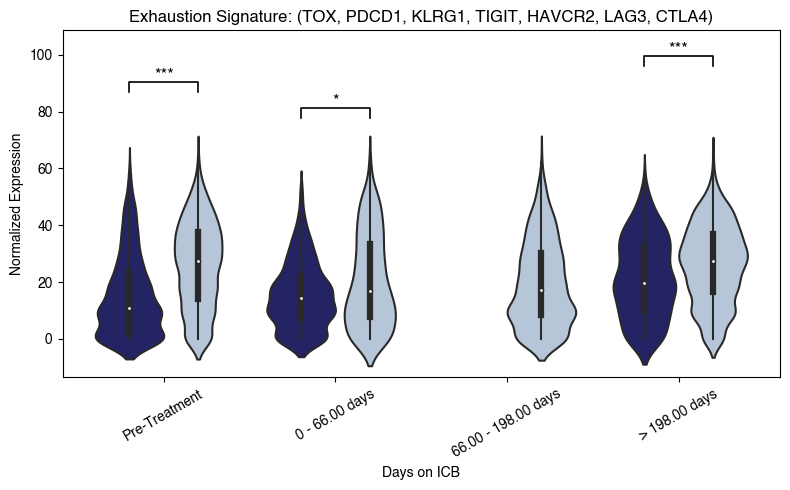

In [19]:
genes = ['TOX', 'PDCD1', 'KLRG1', 'TIGIT', 'HAVCR2', 'LAG3', 'CTLA4']
title = 'Exhaustion Signature: (TOX, PDCD1, KLRG1, TIGIT, HAVCR2, LAG3, CTLA4)'
plot_violin_with_responder_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title=title, figsize=(8,5), save_fig = 'exhaustion_violinplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Stem/Progenitor (Z3)
missing genes:  15 : {'AL353660.1', 'AC002460.2', 'RIPOR2', 'LINC01550', 'SATB1-AS1', 'TMEM131L', 'AL163932.1', 'AC119396.1', 'PATJ', 'AC233976.1', 'RETREG1', 'TMEM272', 'PRKN', 'FP671120.4', 'MCUB'}

--- Significance tests for 'SH3RF3+PRMT2+TNFAIP8+DOCK9+SAMD12+MAGI2+LINC00861+FAM117B+SBF2+SELL+LEF1-AS1+ACTN1+TXNIP+ANK3+TCF7+NRCAM+MPP7+SVIL+SLCO3A1+ADD3+SCML4+PITPNC1+AC093157.1+KCNQ1+MBNL1+RASGRF2+PRKCQ-AS1+CHRM3-AS2+MGAT4A+ITGA6+RASSF3+FOXP1+P2RY8+SORL1+EPHA1-AS1+RASA3+SLC39A10+NBEA+SCML1+TMEM123+NR3C2+PCSK5+PCAT1+ANKH+SSBP2+CAMK4+GNAQ+DENND5A+UBE2E2+TC2N+PLAC8+IGF1R+TRABD2A+OXNAD1+FMN1+TXK+MGAT5+RALGPS2+XIST+EML4+KLF2+MAN1C1+IL7R+RNF144A+BACH2+TMEM63A+CCR7+LEF1+TANC2+MAML2+AK5+SLC16A10+IMMP2L+GLIS3+SERINC5+MAML3+LRRN3+LINC00402+KANK1+LTB+AOAH+S1PR1+APBA2+SAMD3+CDC14A': Responder vs Non-responder within each therapy_bucket ---
  Pre-Treatment: n_R=1026, n_NR=1457, MWU p=4.52e-68, corrected p=6.59e-65
  0 - 66.00 days: n_R=726, n_NR=467, MWU p=0.581, corrected p=1

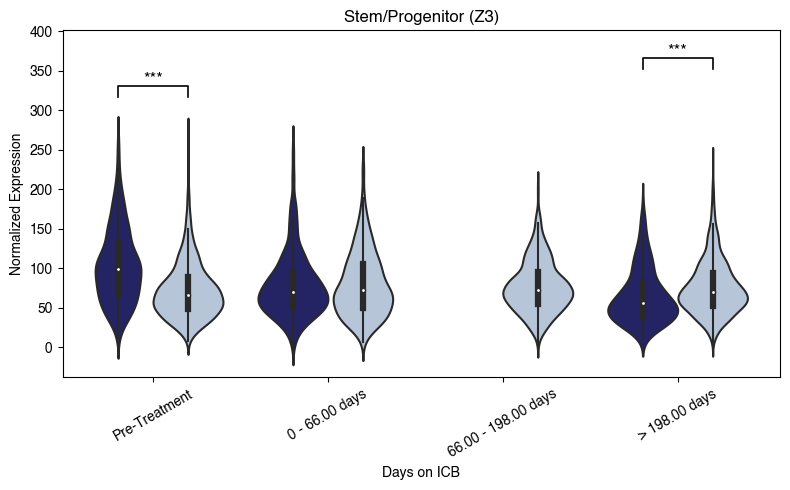

In [20]:
genes = z3.copy()
plot_violin_with_responder_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Stem/Progenitor (Z3)', figsize=(8,5), save_fig='stem_progenitor_z3_violinplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Activation and Cytotoxicity (Z4)
missing genes:  9 : {'LINC02320', 'AC053513.1', 'NIBAN1', 'AC006369.1', 'CRYBG1', 'SLF1', 'AF165147.1', 'MSC-AS1', 'AC068587.4'}

--- Significance tests for 'AGAP1+SLC4A7+IFNG-AS1+STOM+A2M-AS1+STK39+ANXA1+ASAP1+PLCG2+ST8SIA1+C1orf21+KLF6+LINC00278+ANK3+IQGAP2+CLDND1+SLCO3A1+GAB3+CATSPERB+PLCB1+INPP4B+EMB+SH2D1A+IGLV2-14+PHACTR2+ADRB2+MBOAT1+CEP128+TGFBR3+JAKMIP2+GZMA+SLC4A4+MYBL1+SLAMF6+IL32+CCR4+EPHA4+AHNAK+PARP8+TPRG1+MIAT+USP9Y+ARHGAP26+PDCD4+GPRIN3+FCRL6+PTGDR+ATXN1+PPP2R5C+KIAA0825+GBP5+FAR2+TC2N+PPP2R2B+PYHIN1+AUTS2+SMAD3+GPR183+GNG2+HIP1+LCP1+GNAO1+DTHD1+PDE4B+CD69+EML4+PRKY+C12orf75+PLEKHA5+E2F3+ZFP36L2+SLC9A9+CASK+PPP3CA+USP28+GZMK+CCL5+MATK+TTC39C+JAZF1+ERN1+KLRG1+RAP1GAP2+MAP3K5+SLAMF7+LGR6+PZP+PTPRC+AOAH+FYN+SAMD3': Responder vs Non-responder within each therapy_bucket ---
  Pre-Treatment: n_R=1026, n_NR=1457, MWU p=0.865, corrected p=1
  0 - 66.00 days: n_R=726, n_NR=467, MWU p=8.59e-09, corrected p=6.24e-06
  66.00 - 198.00 days: not enoug

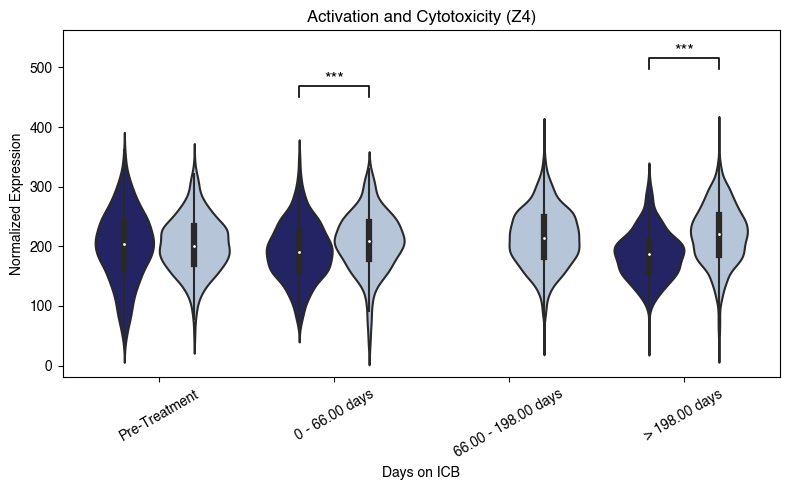

In [21]:
genes = z4.copy()
plot_violin_with_responder_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Activation and Cytotoxicity (Z4)', figsize=(8,5), save_fig = 'activation_cytotoxicity_z4_violinplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Loss of Self-Renewal (Z2)
missing genes:  14 : {'AC022126.1', 'DRAIC', 'PECAM1', 'LINC02694', 'LINC01934', 'MEAK7', 'MIR4435-2HG', 'AF165147.1', 'ADGRE5', 'MSC-AS1', 'AL392086.3', 'PCNX1', 'AC243829.2', 'TOGARAM2'}

--- Significance tests for 'PTPRJ+NAP1L4+ITGAL+UBL3+STK39+CRIM1+SIRPG+CLIC5+PIK3R5+CXCR6+FOXO1+ASAP1+PLCG2+ST8SIA1+MAST4+CD244+CCDC141+LINC00278+FAM53B+KIAA1671+THEMIS+TSPAN5+GAB3+MVB12B+RASA1+EMB+YPEL1+LINC00426+SP4+DZIP3+IGKV4-1+JAKMIP2+IDH2+SNTB2+ZEB1+ABCB1+KLRC4+ITGA1+PARP8+MIAT+DNAJC1+PDCD4+FCRL6+PTGDR+KIAA0825+GBP5+BFSP2-AS1+TC2N+PPP2R2B+SFMBT2+RUNX1+ZNRF1+ITGAE+HIP1+RAP1GDS1+RGS1+FKBP5+DTHD1+ST6GALNAC3+MAP2K6+EPSTI1+DAPK2+ZFP36L2+SLC9A9+TRERF1+USP28+STARD9+ADAMTS17+KATNAL1+SUCLG2+CSF1+MYO5A+ARHGAP18+SPON2+DDIT4+CD38+TET1+MAP3K5+DAB2IP+RUNX2+AOAH+PIK3AP1+CCR9+TTN+HIST1H1E+CMIP': Responder vs Non-responder within each therapy_bucket ---
  Pre-Treatment: n_R=1026, n_NR=1457, MWU p=1.02e-39, corrected p=1.48e-36
  0 - 66.00 days: n_R=726, n_NR=467, MWU p=2.09e-06, correc

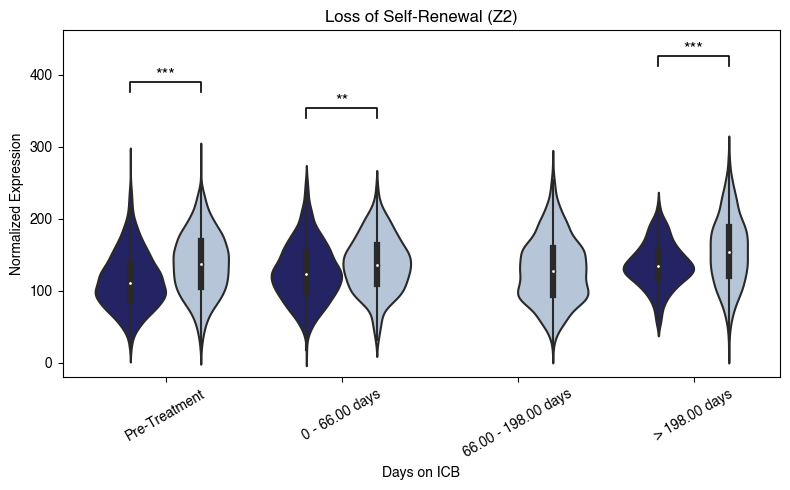

In [22]:
genes = z2.copy()
plot_violin_with_responder_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Loss of Self-Renewal (Z2)', figsize=(8,5), save_fig = 'loss_of_self_renewal_z2_violinplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Exhaustion and Antigen-Presentation (Z9)
missing genes:  8 : {'LINC01943', 'AP001341.1', 'WHRN', 'AL355076.2', 'AL133405.2', 'ADGRG1', 'AL138720.1', 'LINC02416'}

--- Significance tests for 'PTPRJ+TNFRSF9+LY6E+IL2RB+RGS3+ZC3H12C+HLA-A+FTL+CCL4+HAVCR2+CD27+PHLDA1+NCALD+UBE2F+MAN1A1+HLA-DRB1+MTRNR2L12+TIGIT+ATP9A+TAP1+GZMB+LAG3+RDH10+TRPS1+CST7+GNLY+FUT8+MIR155HG+LINC00299+FASLG+KLRD1+CD74+PTMS+GAPDH+NFAT5+OSBPL3+MTSS1+IFNG+CCL3+CTSC+PAM+IGF2R+GOLIM4+GPD2+KIR2DL4+GBP2+UTY+ENTPD1+HLA-B+MAP4K3+CD8A+GBP5+HLA-DPA1+SETBP1+HLA-C+ACTB+TNFRSF1B+VCAM1+CDK6+B2M+TBC1D4+APOBEC3G+CADM1+FAM3C+TMSB4X+RIN3+LYST+PFN1+INPP5F+STAT1+NKG7+MYO7A+CCL5+CSF1+FCRL3+CD7+AC024028.1+PRF1+CD38+TNIP3+ARL6IP1+CDK14+DGKH+AFAP1L2+HCST+ATP8B4+CALR+TOX+PIP5K1B+ZFP36L1+PDE7B+GZMH': Responder vs Non-responder within each therapy_bucket ---
  Pre-Treatment: n_R=1026, n_NR=1457, MWU p=8.18e-106, corrected p=1.19e-102
  0 - 66.00 days: n_R=726, n_NR=467, MWU p=2.37e-23, corrected p=1.72e-20
  66.00 - 198.00 days: not enough dat

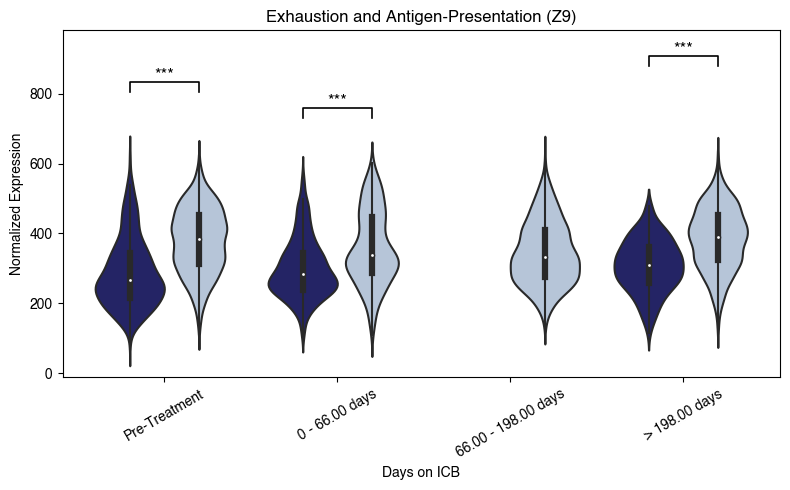

In [23]:
genes = z9.copy()
plot_violin_with_responder_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Exhaustion and Antigen-Presentation (Z9)', figsize=(8,5), save_fig = 'exhaustion_and_antigen_presentation_z9_violinplot')

## lineplots for cell-level expression patterns over days on ICB (within-group significance)

In [24]:
def plot_combined_line_states_with_significance(cd8t, genes, therapy_bucket_order, palette, title=None, figsize=(8, 8), show='median_iqr', save_fig=None):
    """
    Faceted lineplot of gene signature by therapy_bucket, split into 2 rows sharing the
    x-axis: Responder on top, Non-responder on bottom. Each row overlays a median line
    and IQR band, and annotates significant pairwise therapy_bucket comparisons (within
    that response group, Bonferroni-corrected) with significance stars.

    show: 'median_iqr' (default) draws only the median line + IQR band. 'box' additionally
    draws a boxplot underneath. 'violin_box' additionally draws a violin + boxplot underneath.
    """
    genes = genes.copy()
    print(title)
    print("missing genes: ", len(set(genes) - set(cd8t.var_names)), ":", set(genes) - set(cd8t.var_names))
    genes = list(set(genes) & set(cd8t.var_names))

    df = sc.get.obs_df(cd8t, keys=genes + cd8t.obs.columns.tolist())
    key = "+".join(genes)
    df[key] = df[genes].sum(axis=1)

    responses = ['Responder', 'Non-responder']
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    for ax, response in zip(axes, responses):
        sub = df[df['response'] == response]
        color = palette[response]

        if show == 'violin_box':
            sns.violinplot(
                data=sub, x='therapy_bucket', y=key,
                order=therapy_bucket_order, ax=ax, color=color,
            )
        if show in ('box', 'violin_box'):
            sns.boxplot(
                data=sub, x='therapy_bucket', y=key,
                order=therapy_bucket_order, ax=ax, color=color, fill=False, width=0.3,
            )

        groups = sub.groupby('therapy_bucket', observed=True)[key]
        therapy_buckets = [b for b in therapy_bucket_order if b in groups.groups.keys()]
        medians = groups.median().reindex(therapy_buckets)
        q25 = groups.quantile(0.25).reindex(therapy_buckets)
        q75 = groups.quantile(0.75).reindex(therapy_buckets)
        x = [therapy_bucket_order.index(b) for b in therapy_buckets]
        ax.plot(x, medians, color=color, marker='o', label='Median')
        ax.fill_between(x, q25, q75, color=color, alpha=0.2, label='IQR (25-75%)')
        ax.set_ylabel(response+" Normalized Expression")
        ax.set_xlabel('')
        ax.legend().set_visible(False)

        # Pairwise significance between all therapy buckets within this response group
        # (Bonferroni correction: p-value * size of the larger of the two compared groups)
        print(f"\n--- Significance tests for '{title if title else key}', response = {response} ---")
        sig_pairs = []
        for i in range(len(therapy_buckets)):
            for j in range(i + 1, len(therapy_buckets)):
                b1, b2 = therapy_buckets[i], therapy_buckets[j]
                vals1 = sub[sub['therapy_bucket'] == b1][key].dropna()
                vals2 = sub[sub['therapy_bucket'] == b2][key].dropna()
                if len(vals1) >= 2 and len(vals2) >= 2:
                    stat, pval = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
                    n_comparisons = max(len(vals1), len(vals2))
                    pval_corrected = min(pval * n_comparisons, 1.0)
                    print(f'  "{b1}" vs "{b2}": n={len(vals1)} vs {len(vals2)}, MWU p={pval:.3g}, corrected p={pval_corrected:.3g}')
                    sig_pairs.append((therapy_bucket_order.index(b1), therapy_bucket_order.index(b2), pval_corrected))
                else:
                    print(f'  "{b1}" vs "{b2}": not enough data (n={len(vals1)} vs {len(vals2)})')

        add_significance_brackets(ax, sig_pairs)

    axes[-1].set_xticks(range(len(therapy_bucket_order)))
    axes[-1].set_xticklabels(therapy_bucket_order, rotation=30)
    axes[-1].set_xlabel('Days on ICB')
    fig.suptitle(title if title else key)
    plt.tight_layout()
    if save_fig:
        fig.savefig(f'sade-feldman-2018/fig/{save_fig}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Exhaustion Signature
missing genes:  0 : set()

--- Significance tests for 'Exhaustion Signature', response = Responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1026 vs 726, MWU p=0.0195, corrected p=1
  "Pre-Treatment" vs "> 198.00 days": n=1026 vs 297, MWU p=3.05e-13, corrected p=3.13e-10
  "0 - 66.00 days" vs "> 198.00 days": n=726 vs 297, MWU p=2.15e-10, corrected p=1.56e-07

--- Significance tests for 'Exhaustion Signature', response = Non-responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1457 vs 467, MWU p=9.74e-12, corrected p=1.42e-08
  "Pre-Treatment" vs "66.00 - 198.00 days": n=1457 vs 1004, MWU p=6.14e-25, corrected p=8.95e-22
  "Pre-Treatment" vs "> 198.00 days": n=1457 vs 1412, MWU p=0.557, corrected p=1
  "0 - 66.00 days" vs "66.00 - 198.00 days": n=467 vs 1004, MWU p=0.555, corrected p=1
  "0 - 66.00 days" vs "> 198.00 days": n=467 vs 1412, MWU p=1.27e-14, corrected p=1.79e-11
  "66.00 - 198.00 days" vs "> 198.00 days": n=1004 vs 1412, MWU p=9.26e-31, corrected 

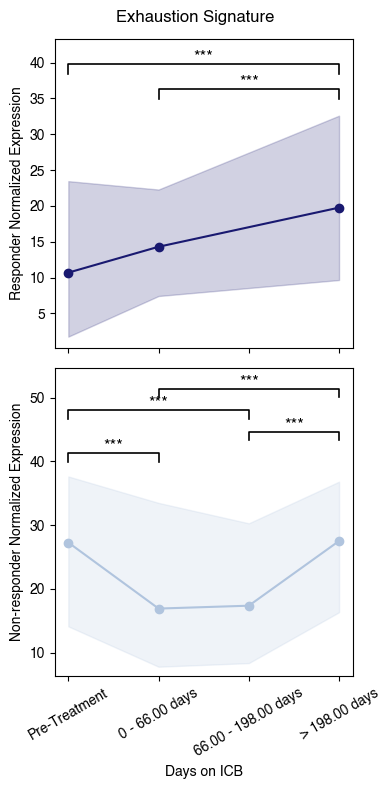

In [25]:
genes = ['TOX', 'PDCD1', 'KLRG1', 'TIGIT', 'HAVCR2', 'LAG3', 'CTLA4']
plot_combined_line_states_with_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Exhaustion Signature', figsize=(4, 8), save_fig = 'exhaustion_signature_lineplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Stem/Progenitor (Z3)
missing genes:  15 : {'AL353660.1', 'AC002460.2', 'RIPOR2', 'LINC01550', 'SATB1-AS1', 'TMEM131L', 'AL163932.1', 'AC119396.1', 'PATJ', 'AC233976.1', 'RETREG1', 'TMEM272', 'PRKN', 'FP671120.4', 'MCUB'}

--- Significance tests for 'Stem/Progenitor (Z3)', response = Responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1026 vs 726, MWU p=1.45e-31, corrected p=1.49e-28
  "Pre-Treatment" vs "> 198.00 days": n=1026 vs 297, MWU p=2.35e-39, corrected p=2.41e-36
  "0 - 66.00 days" vs "> 198.00 days": n=726 vs 297, MWU p=1.53e-08, corrected p=1.11e-05

--- Significance tests for 'Stem/Progenitor (Z3)', response = Non-responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1457 vs 467, MWU p=0.000556, corrected p=0.81
  "Pre-Treatment" vs "66.00 - 198.00 days": n=1457 vs 1004, MWU p=4.06e-07, corrected p=0.000592
  "Pre-Treatment" vs "> 198.00 days": n=1457 vs 1412, MWU p=0.0003, corrected p=0.437
  "0 - 66.00 days" vs "66.00 - 198.00 days": n=467 vs 1004, MWU p=0.969, correct

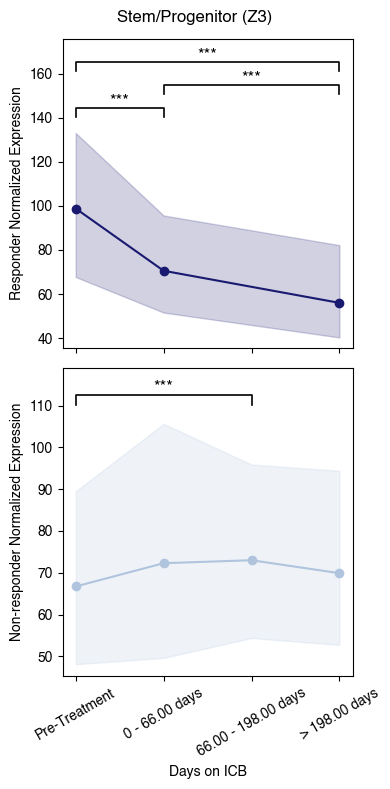

In [26]:
genes = z3.copy()
plot_combined_line_states_with_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Stem/Progenitor (Z3)', figsize=(4, 8), save_fig = 'stem_progenitor_z3_lineplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Activation and Cytotoxicity (Z4)
missing genes:  9 : {'LINC02320', 'AC053513.1', 'NIBAN1', 'AC006369.1', 'CRYBG1', 'SLF1', 'AF165147.1', 'MSC-AS1', 'AC068587.4'}

--- Significance tests for 'Activation and Cytotoxicity (Z4)', response = Responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1026 vs 726, MWU p=0.000247, corrected p=0.253
  "Pre-Treatment" vs "> 198.00 days": n=1026 vs 297, MWU p=3.58e-06, corrected p=0.00367
  "0 - 66.00 days" vs "> 198.00 days": n=726 vs 297, MWU p=0.0611, corrected p=1

--- Significance tests for 'Activation and Cytotoxicity (Z4)', response = Non-responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1457 vs 467, MWU p=0.0119, corrected p=1
  "Pre-Treatment" vs "66.00 - 198.00 days": n=1457 vs 1004, MWU p=1.95e-09, corrected p=2.84e-06
  "Pre-Treatment" vs "> 198.00 days": n=1457 vs 1412, MWU p=1.42e-22, corrected p=2.06e-19
  "0 - 66.00 days" vs "66.00 - 198.00 days": n=467 vs 1004, MWU p=0.0379, corrected p=1
  "0 - 66.00 days" vs "> 198.00 days": n

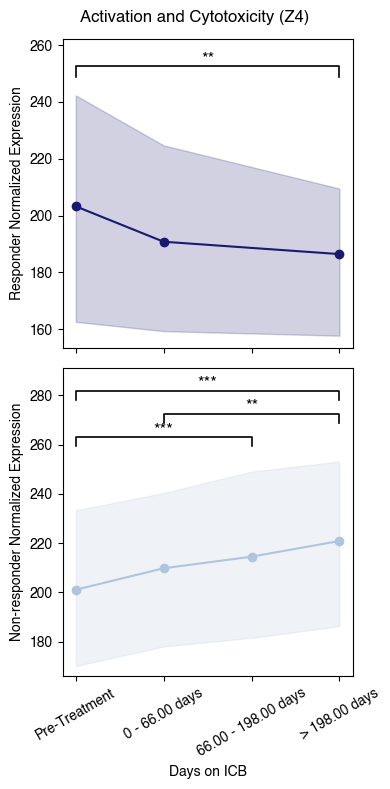

In [27]:
genes = z4.copy()
plot_combined_line_states_with_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Activation and Cytotoxicity (Z4)', figsize=(4, 8), save_fig = 'activation_cytotoxicity_z4_lineplot')

1 extra bytes in post.stringData array


Loss of Self-Renewal (Z2)
missing genes:  14 : {'AC022126.1', 'DRAIC', 'PECAM1', 'LINC02694', 'LINC01934', 'MEAK7', 'MIR4435-2HG', 'AF165147.1', 'ADGRE5', 'MSC-AS1', 'AL392086.3', 'PCNX1', 'AC243829.2', 'TOGARAM2'}

--- Significance tests for 'Loss of Self-Renewal (Z2)', response = Responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1026 vs 726, MWU p=6.01e-10, corrected p=6.17e-07
  "Pre-Treatment" vs "> 198.00 days": n=1026 vs 297, MWU p=3.76e-21, corrected p=3.86e-18
  "0 - 66.00 days" vs "> 198.00 days": n=726 vs 297, MWU p=1.21e-05, corrected p=0.00878

--- Significance tests for 'Loss of Self-Renewal (Z2)', response = Non-responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1457 vs 467, MWU p=0.922, corrected p=1
  "Pre-Treatment" vs "66.00 - 198.00 days": n=1457 vs 1004, MWU p=1.22e-06, corrected p=0.00178
  "Pre-Treatment" vs "> 198.00 days": n=1457 vs 1412, MWU p=1.38e-22, corrected p=2.02e-19
  "0 - 66.00 days" vs "66.00 - 198.00 days": n=467 vs 1004, MWU p=0.000196, cor

'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


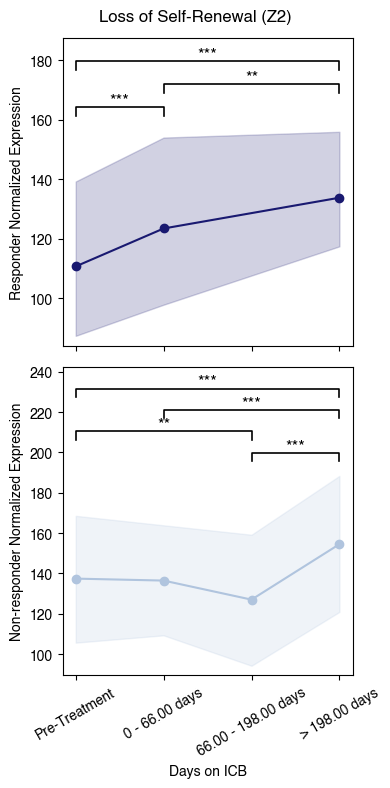

In [28]:
genes = z2.copy()
plot_combined_line_states_with_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Loss of Self-Renewal (Z2)', figsize=(4, 8), save_fig = 'loss_of_self_renewal_z2_lineplot')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Exhaustion and Antigen-Presentation (Z9)
missing genes:  8 : {'LINC01943', 'AP001341.1', 'WHRN', 'AL355076.2', 'AL133405.2', 'ADGRG1', 'AL138720.1', 'LINC02416'}

--- Significance tests for 'Exhaustion and Antigen-Presentation (Z9)', response = Responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1026 vs 726, MWU p=0.000127, corrected p=0.13
  "Pre-Treatment" vs "> 198.00 days": n=1026 vs 297, MWU p=2.41e-07, corrected p=0.000247
  "0 - 66.00 days" vs "> 198.00 days": n=726 vs 297, MWU p=0.0034, corrected p=1

--- Significance tests for 'Exhaustion and Antigen-Presentation (Z9)', response = Non-responder ---
  "Pre-Treatment" vs "0 - 66.00 days": n=1457 vs 467, MWU p=1.12e-05, corrected p=0.0164
  "Pre-Treatment" vs "66.00 - 198.00 days": n=1457 vs 1004, MWU p=1.26e-21, corrected p=1.84e-18
  "Pre-Treatment" vs "> 198.00 days": n=1457 vs 1412, MWU p=0.0842, corrected p=1
  "0 - 66.00 days" vs "66.00 - 198.00 days": n=467 vs 1004, MWU p=0.0231, corrected p=1
  "0 - 66.00 days" vs "> 1

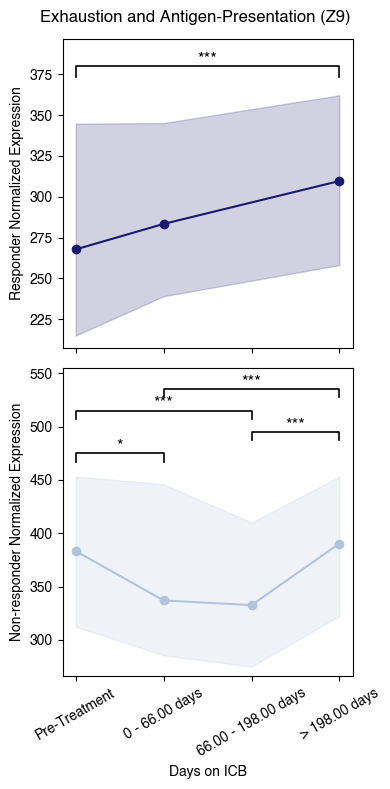

In [29]:
genes = z9.copy()
plot_combined_line_states_with_significance(cd8t, genes, therapy_bucket_order, clinical_variable_palette, title='Exhaustion and Antigen-Presentation (Z9)', figsize=(4, 8), save_fig = 'exhaustion_and_antigen_presentation_z9_lineplot')